# 第35篇｜假设检验：p 值到底是什么意思？

> 这是「数据分析从入门到精通」系列的第 35 篇。置信区间搞懂了，这篇来攻克统计学里最难理解的概念之一——p 值。很多人背下了"p < 0.05 就显著"，但到底为什么？这篇用大白话彻底讲清楚。

---

嗨，我是小荷～

p 值是被**误解最多**的统计概念之一。很多人会说"p < 0.05，所以有显著差异！"——但他们往往不知道这句话背后的逻辑。

今天彻底讲清楚：**假设检验是什么，p 值是什么，怎么用，不能怎么用**。

这也是 A/B 测试的理论基础，电商、互联网公司每天都在用。

---

## 一、假设检验的逻辑

假设检验的逻辑和"无罪推定"一样：

1. 先假设"没有效果"（**零假设 H₀**）
2. 收集数据，看这个数据在 H₀ 成立的情况下有多"奇怪"
3. 如果"足够奇怪"（p 值很小），就拒绝零假设，接受**备择假设 H₁**

---

## 二、p 值的正确定义

> **p 值 = 在零假设成立的前提下，观测到"至少像现在这样极端"的结果的概率。**

**p 值不是**：
- ❌ 零假设是真的概率
- ❌ 效果的大小
- ❌ 研究结论正确的概率

---

## 三、单样本 t 检验

最基础的 t 检验——拿一组数据跟某个固定值比较：


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 场景：某产品声称均值 ¥500，我们抽样 40 个订单，测试是否相符
claimed_mean = 500
sample = np.random.normal(520, 80, 40)   # 实际样本均值约520
# 样本数据和声称均值相比较，
# t_stat，t 统计量衡量的是：样本均值与假设均值之间，差了多少个标准误。
# |t| 越大，p 值越小，它们是单调递减关系，但不是线性反比——|t| 是检验统计量，p 是它在 t 分布下的尾部概率。
t_stat, p_value = stats.ttest_1samp(sample, popmean=claimed_mean)  

print("单样本 t 检验")
print(f"H₀：总体均值 = {claimed_mean}")
print(f"H₁：总体均值 ≠ {claimed_mean}（双尾）")
print(f"样本均值：{sample.mean():.1f}")
print(f"t 统计量：{t_stat:.4f}")
print(f"p 值：{p_value:.4f}")
print()
if p_value < 0.05:
    print("结论：p < 0.05，拒绝零假设，有显著证据表明均值不是 ¥500")
else:
    print("结论：p ≥ 0.05，不能拒绝零假设")


单样本 t 检验
H₀：总体均值 = 500
H₁：总体均值 ≠ 500（双尾）
样本均值：502.5
t 统计量：0.2082
p 值：0.8362

结论：p ≥ 0.05，不能拒绝零假设


---

## 四、p 值可视化

光看数字不够直观，画个图把 p 值的含义"看见"：


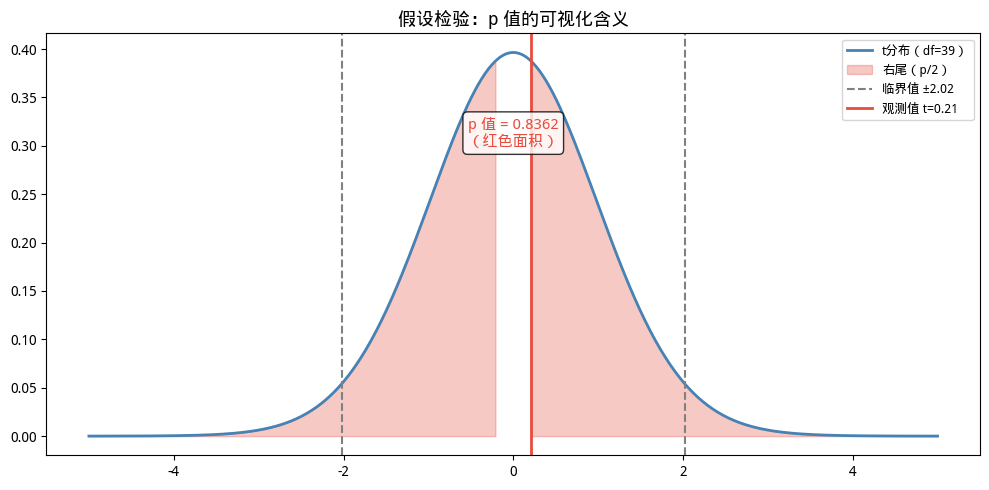

In [2]:
# 可视化 p 值的含义
t_critical = stats.t.ppf(0.975, df=39)   # 双尾，自由度39

t_range = np.linspace(-5, 5, 500)
t_pdf = stats.t.pdf(t_range, df=39)  # 计算 t 分布的概率密度函数（PDF）值

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_range, t_pdf, 'steelblue', linewidth=2, label='t分布（df=39）')

# 填充 p 值区域（两尾）
ax.fill_between(t_range, t_pdf, where=(t_range >= t_stat), color='#E74C3C', alpha=0.3, label=f'右尾（p/2）')
ax.fill_between(t_range, t_pdf, where=(t_range <= -abs(t_stat)), color='#E74C3C', alpha=0.3)

# 临界值
ax.axvline(x=t_critical, color='gray', linestyle='--', linewidth=1.5, label=f'临界值 ±{t_critical:.2f}')
ax.axvline(x=-t_critical, color='gray', linestyle='--', linewidth=1.5)

# 观测的t统计量
ax.axvline(x=t_stat, color='#E74C3C', linewidth=2, label=f'观测值 t={t_stat:.2f}')

ax.text(0, 0.3, f'p 值 = {p_value:.4f}\n（红色面积）',
         ha='center', fontsize=11, color='#E74C3C',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('假设检验：p 值的可视化含义', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**p 值就是图中红色区域的面积**——在零假设成立时，出现"至少这么极端"的结果的概率。

---

## 五、两类错误

| | 实际无差异（H₀为真） | 实际有差异（H₁为真） |
|--|--|--|
| **拒绝 H₀** | 第一类错误 α（假阳性） | ✅ 正确（检验效力 1-β） |
| **不拒绝 H₀** | ✅ 正确 | 第二类错误 β（假阴性） |

- **α（显著性水平）**：通常设为 0.05，控制假阳性率
- **β（第二类错误率）**：通常希望 β ≤ 0.2（检验效力 ≥ 80%）
- 降低 α 会提高 β；只有增大样本量才能同时降低两者


In [3]:
# 直观演示：不同 α 的取舍
for alpha in [0.10, 0.05, 0.01]:
    reject = p_value < alpha
    print(f"α = {alpha}：{'拒绝 H₀（显著）' if reject else '不拒绝 H₀（不显著）'}")


α = 0.1：不拒绝 H₀（不显著）
α = 0.05：不拒绝 H₀（不显著）
α = 0.01：不拒绝 H₀（不显著）


---

## 六、效应量（Effect Size）：p 值之外

p 值只告诉你"是否有差异"，不告诉你"差异有多大"。**效应量** Cohen's d 衡量实际差异大小：


In [4]:
# Cohen's d
d = (sample.mean() - claimed_mean) / sample.std()
print(f"\nCohen's d = {d:.3f}")
print("效应量解读：")
print("  |d| < 0.2：极小效应")
print("  0.2 ≤ |d| < 0.5：小效应")
print("  0.5 ≤ |d| < 0.8：中效应")
print("  |d| ≥ 0.8：大效应")



Cohen's d = 0.033
效应量解读：
  |d| < 0.2：极小效应
  0.2 ≤ |d| < 0.5：小效应
  0.5 ≤ |d| < 0.8：中效应
  |d| ≥ 0.8：大效应


> 💡 **重要**：大样本量下，即使很微小的差异也会得到 p < 0.05。这时候效应量比 p 值更重要——差异是否有实际意义？

---

## 七、🔧 综合实战：A/B 测试假设检验

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [7]:
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
import matplotlib.pyplot as plt

np.random.seed(2024)

# 场景：对比新旧两个页面的转化率
# A 组（旧页面）：1000 人，90 人转化
# B 组（新页面）：1000 人，115 人转化

n_a, conv_a = 1000, 90
n_b, conv_b = 1000, 115

p_a = conv_a / n_a
p_b = conv_b / n_b
p_pool = (conv_a + conv_b) / (n_a + n_b)

# 计算 z 统计量（比例检验）
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
z_stat  = (p_b - p_a) / se_pool
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))   # 双尾

print("A/B 测试结果")
print("="*45)
print(f"A 组转化率：{p_a:.2%}（{conv_a}/{n_a}）")
print(f"B 组转化率：{p_b:.2%}（{conv_b}/{n_b}）")
print(f"相对提升：{(p_b-p_a)/p_a:.2%}")
print(f"z 统计量：{z_stat:.4f}")
print(f"p 值：{p_value:.4f}")
print()

if p_value < 0.05:
    print("✅ 结论：p < 0.05，B 组转化率显著高于 A 组，可以上线新页面！")
else:
    print("❌ 结论：p ≥ 0.05，差异不显著，继续测试或不上线。")

# 95% 置信区间（差值）
ci_diff = proportion_confint(conv_b - conv_a, n_a + n_b, alpha=0.05, method='normal')
diff = p_b - p_a
se_diff = np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)
ci = (diff - 1.96 * se_diff, diff + 1.96 * se_diff)
print(f"\n转化率差值 95% 置信区间：({ci[0]:.4f}, {ci[1]:.4f})")
print(f"即差值为 {diff:.2%}，区间约为 ({ci[0]:.2%}, {ci[1]:.2%})")


A/B 测试结果
A 组转化率：9.00%（90/1000）
B 组转化率：11.50%（115/1000）
相对提升：27.78%
z 统计量：1.8431
p 值：0.0653

❌ 结论：p ≥ 0.05，差异不显著，继续测试或不上线。

转化率差值 95% 置信区间：(-0.0016, 0.0516)
即差值为 2.50%，区间约为 (-0.16%, 5.16%)


---

## 八、p 值的常见误用

| 误用 | 正确理解 |
|------|---------|
| p < 0.05 就代表效果很大 | p 值只说明是否显著，不说明大小 |
| p = 0.06 就代表没效果 | 阈值是人为规定的，0.06 也可能有意义 |
| 多次测试直到 p < 0.05 | 多重比较会虚增假阳性率（需要 Bonferroni 校正） |
| p 值越小效果越好 | 大样本下微小差异也能得到极小 p 值 |

---

## 九、📝 小结

| 步骤 | 内容 |
|------|------|
| 1 | 提出零假设 H₀ 和备择假设 H₁ |
| 2 | 设定显著性水平 α（通常 0.05） |
| 3 | 计算检验统计量和 p 值 |
| 4 | p < α 则拒绝 H₀ |
| 5 | 计算效应量，判断差异的实际意义 |

---

## 十、🏋️ 课后练习

1. A 页面 500 次展示，点击率 5%；B 页面 500 次展示，点击率 7.2%。做假设检验，p 值是多少？能否推广 B？
2. 计算上面结果的效应量 Cohen's d（对二元结果可用 Cohen's h），判断实际效应大小。
3. 如果把上题的样本量增加到每组 2000，p 值会如何变化？效应量会变吗？

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [8]:
# 练习1: A/B测试假设检验
print("练习1: A/B测试假设检验")

# 参数设置
n_A = 500    # A组样本量
n_B = 500    # B组样本量
clicks_A = 25   # A组点击数 (5%)
clicks_B = 36   # B组点击数 (7.2%)

# 计算转化率
p_A = clicks_A / n_A
p_B = clicks_B / n_B

print(f"【实验数据】")
print(f"  A组: 展示 {n_A} 次, 点击 {clicks_A} 次, 点击率 = {p_A*100:.2f}%")
print(f"  B组: 展示 {n_B} 次, 点击 {clicks_B} 次, 点击率 = {p_B*100:.2f}%")
print(f"  差异: {p_B - p_A:.4f} = {(p_B - p_A)*100:.2f}%")

# 假设检验
# H0: p_A = p_B (两组转化率无差异)
# H1: p_A ≠ p_B (两组转化率有差异)

# 合并比例 ( pooled proportion )
p_pooled = (clicks_A + clicks_B) / (n_A + n_B)

# 计算标准误
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_A + 1/n_B))

# 计算Z统计量
z_stat = (p_B - p_A) / se_pooled

# 计算p值 (双侧检验)
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"\n【假设检验】")
print(f"  H0: p_A = p_B (两组转化率无差异)")
print(f"  H1: p_A ≠ p_B (两组转化率有差异)")
print(f"\n  合并比例 p_pooled = ({clicks_A} + {clicks_B}) / ({n_A} + {n_B}) = {p_pooled:.4f}")
print(f"  合并标准误 SE = √[p(1-p)(1/n_A + 1/n_B)] = {se_pooled:.6f}")
print(f"\n  Z统计量 = (p_B - p_A) / SE = ({p_B:.4f} - {p_A:.4f}) / {se_pooled:.6f} = {z_stat:.4f}")
print(f"  p值 (双侧) = 2 × P(Z > |{z_stat:.4f}|) = {p_value:.6f}")

# 判断结论
alpha = 0.05
print(f"\n【统计结论】(α = {alpha})")
if p_value < alpha:
    print(f"  p值 ({p_value:.6f}) < α ({alpha})")
    print(f"  结论: 拒绝原假设，两组转化率存在显著差异")
else:
    print(f"  p值 ({p_value:.6f}) >= α ({alpha})")
    print(f"  结论: 不能拒绝原假设，两组转化率无显著差异")

print(f"\n【实际意义】")
print(f"  虽然B组点击率(7.2%)比A组(5%)提高了 {(p_B/p_A-1)*100:.1f}%")
print(f"  但在当前样本量下，p值 = {p_value:.4f} > 0.05")
print(f"  我们没有足够的统计证据来推广B页面")

练习1: A/B测试假设检验
【实验数据】
  A组: 展示 500 次, 点击 25 次, 点击率 = 5.00%
  B组: 展示 500 次, 点击 36 次, 点击率 = 7.20%
  差异: 0.0220 = 2.20%

【假设检验】
  H0: p_A = p_B (两组转化率无差异)
  H1: p_A ≠ p_B (两组转化率有差异)

  合并比例 p_pooled = (25 + 36) / (500 + 500) = 0.0610
  合并标准误 SE = √[p(1-p)(1/n_A + 1/n_B)] = 0.015137

  Z统计量 = (p_B - p_A) / SE = (0.0720 - 0.0500) / 0.015137 = 1.4534
  p值 (双侧) = 2 × P(Z > |1.4534|) = 0.146104

【统计结论】(α = 0.05)
  p值 (0.146104) >= α (0.05)
  结论: 不能拒绝原假设，两组转化率无显著差异

【实际意义】
  虽然B组点击率(7.2%)比A组(5%)提高了 44.0%
  但在当前样本量下，p值 = 0.1461 > 0.05
  我们没有足够的统计证据来推广B页面


In [9]:
# 练习2: 效应量 Cohen's h
print("练习2: 效应量 Cohen's h")

# Cohen's h 定义: h = 2 * arcsin(√p1) - 2 * arcsin(√p2)
# 或者 h = 2 * arcsin(√p_B) - 2 * arcsin(√p_A)

h = 2 * (np.arcsin(np.sqrt(p_B)) - np.arcsin(np.sqrt(p_A)))

print(f"【Cohen's h 计算】")
print(f"  Cohen's h = 2 × arcsin(√p_B) - 2 × arcsin(√p_A)")
print(f"            = 2 × arcsin(√{p_B:.4f}) - 2 × arcsin(√{p_A:.4f})")
print(f"            = 2 × {np.arcsin(np.sqrt(p_B)):.4f} - 2 × {np.arcsin(np.sqrt(p_A)):.4f}")
print(f"            = {h:.4f}")

# Cohen's h 的解释标准
# |h| < 0.2: 微小效应
# 0.2 <= |h| < 0.5: 小效应
# 0.5 <= |h| < 0.8: 中等效应
# |h| >= 0.8: 大效应

abs_h = abs(h)
if abs_h < 0.2:
    effect_size = "微小效应"
elif abs_h < 0.5:
    effect_size = "小效应"
elif abs_h < 0.8:
    effect_size = "中等效应"
else:
    effect_size = "大效应"

print(f"\n【效应量解释】")
print(f"  |h| = {abs_h:.4f}")
print(f"  效应大小: {effect_size}")
print(f"\n  Cohen's h 解释标准:")
print(f"    |h| < 0.2: 微小效应")
print(f"    0.2 <= |h| < 0.5: 小效应")
print(f"    0.5 <= |h| < 0.8: 中等效应")
print(f"    |h| >= 0.8: 大效应")

print(f"\n【结论】")
print(f"  效应量 |h| = {abs_h:.4f} 属于 {effect_size}")
print(f"  即使统计显著，实际效应也非常小，实际业务意义有限")

练习2: 效应量 Cohen's h
【Cohen's h 计算】
  Cohen's h = 2 × arcsin(√p_B) - 2 × arcsin(√p_A)
            = 2 × arcsin(√0.0720) - 2 × arcsin(√0.0500)
            = 2 × 0.2717 - 2 × 0.2255
            = 0.0923

【效应量解释】
  |h| = 0.0923
  效应大小: 微小效应

  Cohen's h 解释标准:
    |h| < 0.2: 微小效应
    0.2 <= |h| < 0.5: 小效应
    0.5 <= |h| < 0.8: 中等效应
    |h| >= 0.8: 大效应

【结论】
  效应量 |h| = 0.0923 属于 微小效应
  即使统计显著，实际效应也非常小，实际业务意义有限


In [10]:
# 练习3: 样本量增加对p值和效应量的影响
print("练习3: 样本量增加对p值和效应量的影响")

# 保持相同的转化率，但增加样本量
n_large = 2000

# 计算新的统计量
clicks_A_large = int(p_A * n_large)  # 保持相同比例
clicks_B_large = int(p_B * n_large)

p_A_large = clicks_A_large / n_large
p_B_large = clicks_B_large / n_large

p_pooled_large = (clicks_A_large + clicks_B_large) / (n_large + n_large)
se_pooled_large = np.sqrt(p_pooled_large * (1 - p_pooled_large) * (2/n_large))
z_stat_large = (p_B_large - p_A_large) / se_pooled_large
p_value_large = 2 * (1 - stats.norm.cdf(abs(z_stat_large)))

# Cohen's h 保持不变 (效应量与样本量无关)
h_large = 2 * (np.arcsin(np.sqrt(p_B_large)) - np.arcsin(np.sqrt(p_A_large)))

print(f"【扩大样本量后的结果】(每组 n = {n_large})")
print(f"  A组: {clicks_A_large} / {n_large} = {p_A_large*100:.2f}%")
print(f"  B组: {clicks_B_large} / {n_large} = {p_B_large*100:.2f}%")
print(f"\n  Z统计量 = {z_stat_large:.4f}")
print(f"  p值 = {p_value_large:.10f}")

if p_value_large < 0.05:
    print(f"\n  结论: p值 < 0.05，可以拒绝原假设")
else:
    print(f"\n  结论: p值 >= 0.05，不能拒绝原假设")

print(f"\n  Cohen's h = {h_large:.4f} (与之前相同)")

print(f"\n【对比分析】")
print(f"{'指标':<15} {'n=500':<20} {'n=2000':<20} {'变化'}")
print("-" * 60)
print(f"{'p值':<15} {p_value:<20.6f} {p_value_large:<20.10f} {'显著减小' if p_value_large < p_value else '增大'}")
print(f"{'效应量 h':<15} {h:<20.4f} {h_large:<20.4f} {'不变'}")
print(f"{'|h|':<15} {abs(h):<20.4f} {abs(h_large):<20.4f} {'不变'}")

print(f"\n【重要结论】")
print(f"  1. 当样本量增加时，p值会减小（更容易达到显著性）")
print(f"  2. 效应量 Cohen's h 保持不变（它只与比例有关，与样本量无关）")
print(f"  3. 这说明：统计显著性 ≠ 实际重要性")
print(f"     即使p值变得显著，实际效应仍然很小")

练习3: 样本量增加对p值和效应量的影响
【扩大样本量后的结果】(每组 n = 2000)
  A组: 100 / 2000 = 5.00%
  B组: 144 / 2000 = 7.20%

  Z统计量 = 2.9069
  p值 = 0.0036506990

  结论: p值 < 0.05，可以拒绝原假设

  Cohen's h = 0.0923 (与之前相同)

【对比分析】
指标              n=500                n=2000               变化
------------------------------------------------------------
p值              0.146104             0.0036506990         显著减小
效应量 h           0.0923               0.0923               不变
|h|             0.0923               0.0923               不变

【重要结论】
  1. 当样本量增加时，p值会减小（更容易达到显著性）
  2. 效应量 Cohen's h 保持不变（它只与比例有关，与样本量无关）
  3. 这说明：统计显著性 ≠ 实际重要性
     即使p值变得显著，实际效应仍然很小


本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 36 篇：常用检验方法 — t 检验 / 卡方检验 / 方差分析**
>
> 知道了 p 值，下篇来学具体的检验方法：t 检验、卡方检验、方差分析，对应不同的数据类型和检验场景。

---

*跟着小荷，数据分析路上不迷路～*